<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/python_/blob/main/04_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# INSTALL LIBRARIES
!pip install shap lime dalex scikit-learn matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 52.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import dalex as dx

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from lime.lime_tabular import LimeTabularExplainer

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [ ]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# SCALING (IMPORTANT FOR LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# TRAIN MODEL (BEST MODEL EXAMPLE)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)


--- SHAP EXPLANATION ---


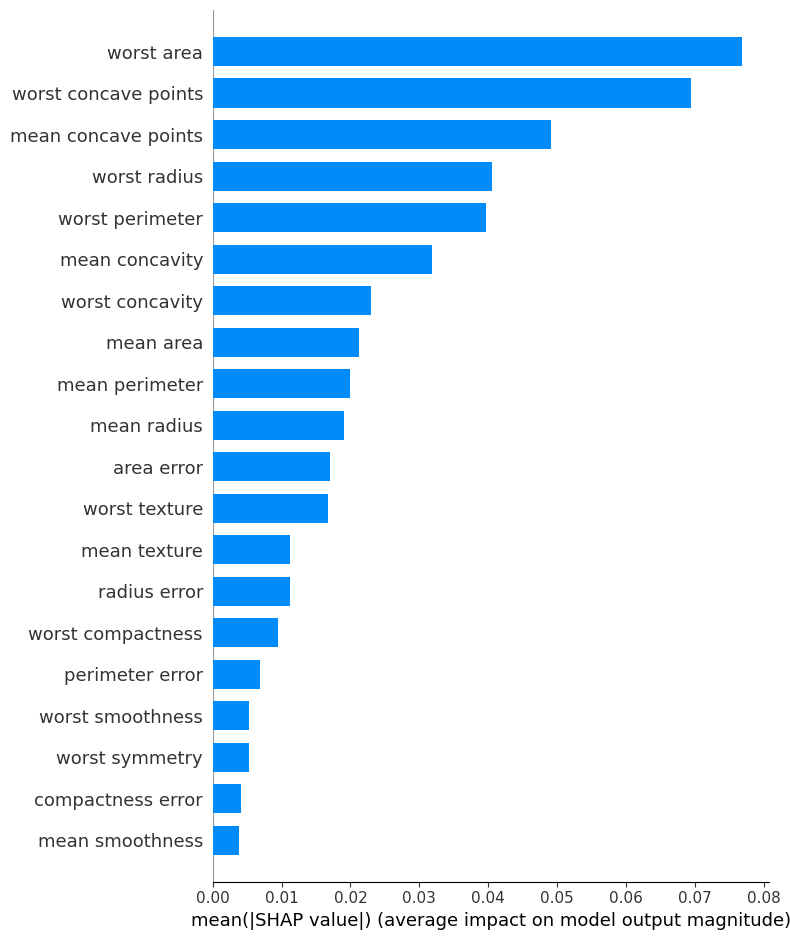

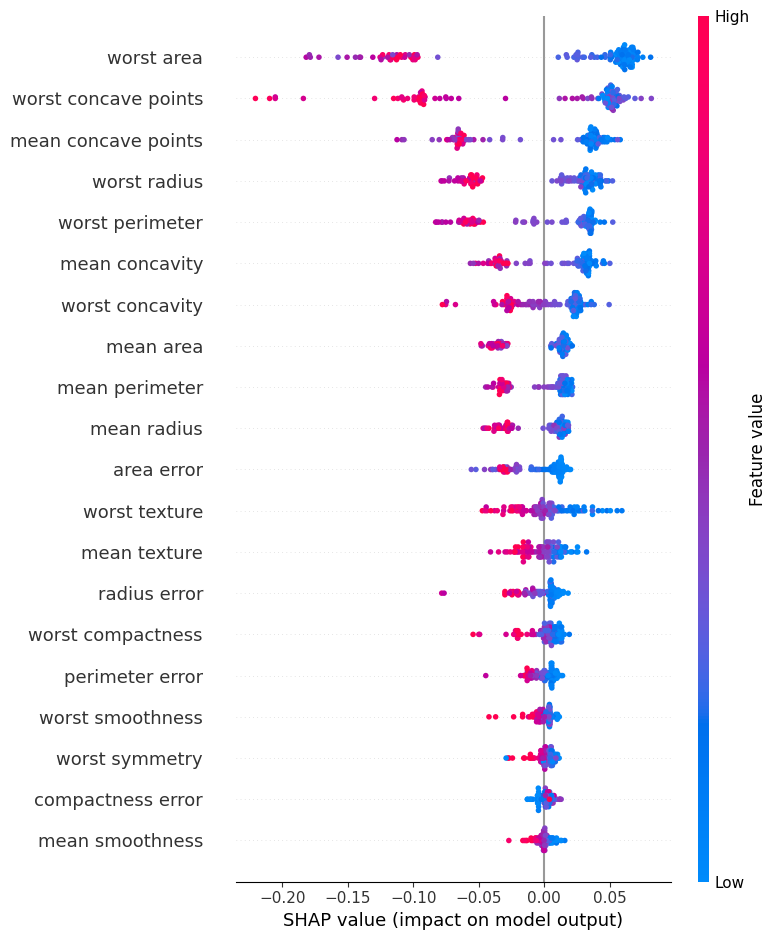

<Figure size 640x480 with 0 Axes>

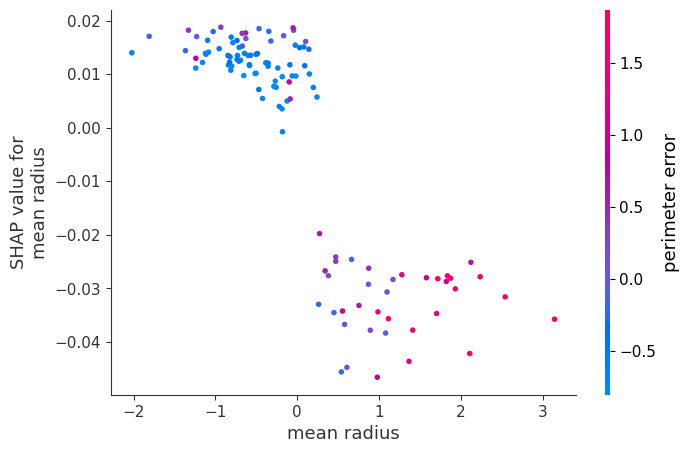

<Figure size 640x480 with 0 Axes>

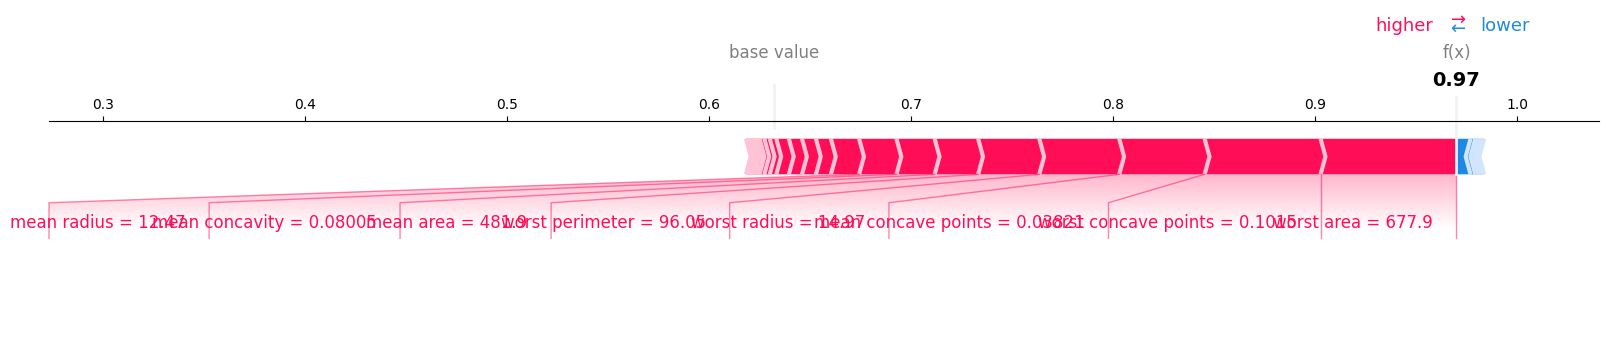

In [ ]:

#  SHAP EXPLAINABILITY

print("\n--- SHAP EXPLANATION ---")

import shap

# Use TreeExplainer (since RandomForest is tree-based)
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification:
# shap_values is a list of arrays if the model's predict_proba has shape (N, 2)
# or a single 3D array if the model's predict_proba has shape (N, F, 2).
# Given the traceback, it seems `explainer.shap_values` returns a 3D array (num_samples, num_features, num_classes).
# We usually explain class_1
shap_vals = shap_values[:, :, 1] # Correctly extract SHAP values for class 1 across all samples and features

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
plt.figure()
shap.summary_plot(shap_vals, X_test_scaled, feature_names=X.columns, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
plt.figure()
shap.summary_plot(shap_vals, X_test_scaled, feature_names=X.columns)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
# Change feature name as needed
plt.figure()
shap.dependence_plot(
    X.columns[0],  # example feature
    shap_vals,
    X_test_scaled, # Use scaled data here
    feature_names=X.columns # Provide feature names for clarity
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
# Use expected value of class 1
expected_value = explainer.expected_value[1]

plt.figure()
shap.force_plot(
    expected_value,
    shap_vals[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
    X_test.iloc[0],
    matplotlib=True
)

In [ ]:
#  LIME EXPLAINABILITY

print("\n--- LIME EXPLANATION ---")

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    mode='classification'
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    model.predict_proba
)

lime_exp.show_in_notebook(show_table=True)




--- LIME EXPLANATION ---


In [ ]:
#  DALEX EXPLAINABILITY
print("\n--- DALEX EXPLANATION ---")

# Create explainer
explainer_dx = dx.Explainer(
    model,
    X_train_scaled,
    y_train,
    label="Random Forest"
)


--- DALEX EXPLANATION ---
Preparation of a new explainer is initiated

  -> data              : numpy.ndarray converted to pandas.DataFrame. Columns are set as string numbers.
  -> data              : 455 rows 30 cols
  -> target variable   : 455 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest
  -> predict function  : <function yhat_proba_default at 0x7e00d0944ae0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.63, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.45, mean = -0.0011, max = 0.29
  -> model_info        : package sklearn

A new explainer has been created!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:


# Feature Importance
fi = explainer_dx.model_parts()
fi.plot()

# Predict Explanation (local)
obs = X_test_scaled[0]
bd = explainer_dx.predict_parts(obs, type='break_down')
bd.plot()

# Model Performance
mp = explainer_dx.model_performance()
mp.plot()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U